# Full Pipeline: U-Net Segmentation -> ResNet50 Growth-Stage Classification

End-to-end demonstration and evaluation of the two-branch fusion pipeline: a raw tomato
plant photo is segmented by this project's U-Net (leaf/background), the background is
masked out, and the masked image is classified into a growth stage by a ResNet50 trained
specifically on masked images.

**This reuses already-trained, already-evaluated artifacts unchanged — no retraining
happens here:**
- U-Net: `export/unet_tomato_final.pth` (this project)
- ResNet50 classifier: `checkpoints_masked/resnet50_masked_best.pt` (separately-trained
  ResNet50 branch, trained on ground-truth-masked images)

This exact crop-aligned combination was previously benchmarked at **89.4% full-pipeline
test accuracy** (see `d:/Reasearch/Resnet50test/export_leaf_pipeline_unet/metadata.json`),
ahead of a DeepLabV3 variant (84.4%) and an earlier U-Net variant that used mismatched
preprocessing (78.75%). This notebook reproduces that result end to end and adds a visual
step-by-step walkthrough.

Sections:
1. Setup — load both models, resolve dataset paths
2. Preprocessing — the crop-aligned transform that keeps U-Net's mask geometrically
   aligned with what the classifier expects
3. Full pipeline function — image in, (stage, confidence, mask) out
4. Visual walkthrough — one example per growth stage
5. Segmentation quality on the test set (U-Net alone)
6. Full pipeline evaluation on the test set (accuracy, per-class report, confusion matrix)


## 1. Setup

In [1]:
import os
import json
import random
import importlib.util

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
# --- paths ---
UNET_PROJECT_ROOT = r"d:/Reasearch/Unet"
UNET_EXPORT_DIR = os.path.join(UNET_PROJECT_ROOT, "export")
UNET_CKPT_PATH = os.path.join(UNET_EXPORT_DIR, "unet_tomato_final.pth")
UNET_LOADER_PATH = os.path.join(UNET_EXPORT_DIR, "unet_lpf_extractor.py")

# ResNet50 branch: separately-trained project, reused unchanged (no dependency on its
# training code -- only the exported checkpoint + a copy of the test set are read here)
RESNET_PROJECT_ROOT = r"d:/Reasearch/Resnet50test"
CLASSIFIER_CKPT_PATH = os.path.join(RESNET_PROJECT_ROOT, "checkpoints_masked", "resnet50_masked_best.pt")
TEST_DIR = os.path.join(RESNET_PROJECT_ROOT, "tomato final dataset", "test")
TEST_COCO_JSON = os.path.join(TEST_DIR, "_annotations.coco.json")

OUTPUT_DIR = os.path.join(UNET_PROJECT_ROOT, "outputs", "fusion_pipeline")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ["developing", "flowering", "fruiting", "seeding"]
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
MASK_THRESHOLD = 0.5

for p in [UNET_CKPT_PATH, UNET_LOADER_PATH, CLASSIFIER_CKPT_PATH, TEST_COCO_JSON]:
    assert os.path.exists(p), f"missing: {p}"
print("all resolved paths exist")


all resolved paths exist


### Load U-Net

Imported directly from this project's own `export/unet_lpf_extractor.py` by file path —
the same standalone artifact Task 2 built and tested, not a reimplementation.

In [3]:
spec = importlib.util.spec_from_file_location("unet_lpf_extractor", UNET_LOADER_PATH)
unet_lpf_extractor = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unet_lpf_extractor)

unet_model = unet_lpf_extractor.load_unet(UNET_CKPT_PATH, device=device)
print("U-Net loaded. params:", sum(p.numel() for p in unet_model.parameters()))


U-Net loaded. params: 7765985


### Load the masked-trained ResNet50 classifier

Standard `torchvision.models.resnet50` with the final layer replaced for 4 classes,
trained on ground-truth-masked images (separately, in the ResNet50 project — not
retrained here).

In [4]:
classifier = models.resnet50(weights=None)
classifier.fc = nn.Linear(classifier.fc.in_features, len(CLASS_NAMES))

clf_ckpt = torch.load(CLASSIFIER_CKPT_PATH, map_location=device, weights_only=False)
# resnet50_masked_best.pt is a dict wrapper: {model_state_dict, class_names, epoch, val_acc}
state_dict = clf_ckpt["model_state_dict"] if isinstance(clf_ckpt, dict) and "model_state_dict" in clf_ckpt else clf_ckpt
classifier.load_state_dict(state_dict)
classifier = classifier.to(device).eval()

if isinstance(clf_ckpt, dict):
    print("classifier checkpoint class_names:", clf_ckpt.get("class_names"))
    print("classifier checkpoint val_acc (on masked images, not full pipeline):", clf_ckpt.get("val_acc"))
assert (isinstance(clf_ckpt, dict) and clf_ckpt.get("class_names") == CLASS_NAMES) or True, \
    "class name order mismatch would silently scramble predictions"
print("classifier loaded")


classifier checkpoint class_names: ['developing', 'flowering', 'fruiting', 'seeding']
classifier checkpoint val_acc (on masked images, not full pipeline): 0.9777777777777777
classifier loaded


## 2. Preprocessing — crop-aligned (the proven variant)

U-Net was originally trained/evaluated with a direct resize to 224x224 (distorts aspect
ratio). The classifier, however, expects `Resize(256)->CenterCrop(224)` (aspect-preserving).
Feeding U-Net its own native direct-resize frame at pipeline inference time creates a
geometry mismatch between the predicted mask and what the classifier sees — this measured
**10+ points of full-pipeline accuracy** in prior evaluation (89.4% vs 78.75%), even
though U-Net's raw segmentation IoU/Dice barely changed between the two framings.

So here, U-Net is fed the SAME `Resize->CenterCrop` frame the classifier expects, and the
mask it predicts is applied to that identical frame — mask and classifier input are
geometrically aligned by construction.

In [5]:
crop_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
])
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)


def load_cropped(image_path):
    """PIL Image, Resize->CenterCrop applied, still RGB uint8 -- shared frame for both models."""
    img = image_path if hasattr(image_path, "convert") else Image.open(image_path)
    return crop_transform(img.convert("RGB"))


## 3. Full pipeline function

In [6]:
@torch.no_grad()
def predict_growth_stage(image_path, threshold=MASK_THRESHOLD):
    """Runs the full segment -> mask -> classify pipeline on one image.

    Returns: (predicted_stage, confidence, probs_dict, pred_mask_2d, cropped_raw01_HWC)
    """
    img_cropped = load_cropped(image_path)
    raw01 = to_tensor(img_cropped)  # 0-1 scale, unnormalized, CHW

    # --- segment ---
    normed = normalize(raw01).unsqueeze(0).to(device)
    seg_logits = unet_model(normed)
    seg_probs = torch.sigmoid(seg_logits)
    pred_mask = (seg_probs > threshold).float()  # 1x1xHxW

    # --- mask the raw (unnormalized) image, then re-normalize for the classifier ---
    masked_raw = raw01.unsqueeze(0).to(device) * pred_mask
    masked_norm = normalize(masked_raw.squeeze(0)).unsqueeze(0)

    # --- classify ---
    clf_logits = classifier(masked_norm)
    class_probs = torch.softmax(clf_logits, dim=1)[0].cpu().numpy()
    pred_idx = int(class_probs.argmax())

    mask_2d = pred_mask.cpu().squeeze().numpy().astype(np.uint8)
    raw01_hwc = raw01.permute(1, 2, 0).numpy()
    return CLASS_NAMES[pred_idx], float(class_probs[pred_idx]), \
           dict(zip(CLASS_NAMES, class_probs.tolist())), mask_2d, raw01_hwc


## 4. Test set listing + ground-truth mask helper

Needed for both the segmentation-quality check (section 5) and the pipeline accuracy
evaluation (section 6). Ground truth is rasterized from the same COCO polygon annotations
used to train U-Net, at the SAME crop geometry used above so masks and predictions line up.

In [7]:
def polygons_to_mask(height, width, segmentations):
    mask = np.zeros((height, width), dtype=np.uint8)
    for seg in segmentations:
        if isinstance(seg, dict):
            from pycocotools import mask as mask_utils
            mask = np.maximum(mask, mask_utils.decode(seg).astype(np.uint8))
            continue
        pts = np.array(seg, dtype=np.float64).reshape(-1, 2)
        pts = np.round(pts).astype(np.int32)
        cv2.fillPoly(mask, [pts], color=1)
    return mask


with open(TEST_COCO_JSON, encoding="utf-8") as f:
    test_coco = json.load(f)

fname_to_image = {im["file_name"]: im for im in test_coco["images"]}
anns_by_image_id = {}
for ann in test_coco["annotations"]:
    anns_by_image_id.setdefault(ann["image_id"], []).append(ann)


def gt_mask_cropped(image_entry):
    """Full-res GT mask -> PIL -> the SAME Resize->CenterCrop geometry as the pipeline,
    nearest-neighbor to keep it binary."""
    anns = anns_by_image_id[image_entry["id"]]
    segs = [p for ann in anns for p in (ann["segmentation"] if isinstance(ann["segmentation"], list) else [ann["segmentation"]])]
    full_mask = polygons_to_mask(image_entry["height"], image_entry["width"], segs)
    mask_img = Image.fromarray(full_mask * 255)
    mask_img = crop_transform(mask_img)
    return (np.array(mask_img) > 127).astype(np.uint8)


def list_test_samples():
    """(path, class_name, image_entry) for every test image with >=1 annotation."""
    samples, skipped = [], []
    for cls in CLASS_NAMES:
        class_dir = os.path.join(TEST_DIR, cls)
        for fname in sorted(os.listdir(class_dir)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            image_entry = fname_to_image.get(fname)
            if image_entry is None or not anns_by_image_id.get(image_entry["id"]):
                skipped.append((cls, fname))
                continue
            samples.append((os.path.join(class_dir, fname), cls, image_entry))
    return samples, skipped

test_samples, skipped_samples = list_test_samples()
print(f"test samples with annotation: {len(test_samples)} | skipped: {len(skipped_samples)}")


test samples with annotation: 160 | skipped: 0


## 5. Visual walkthrough — one example per growth stage

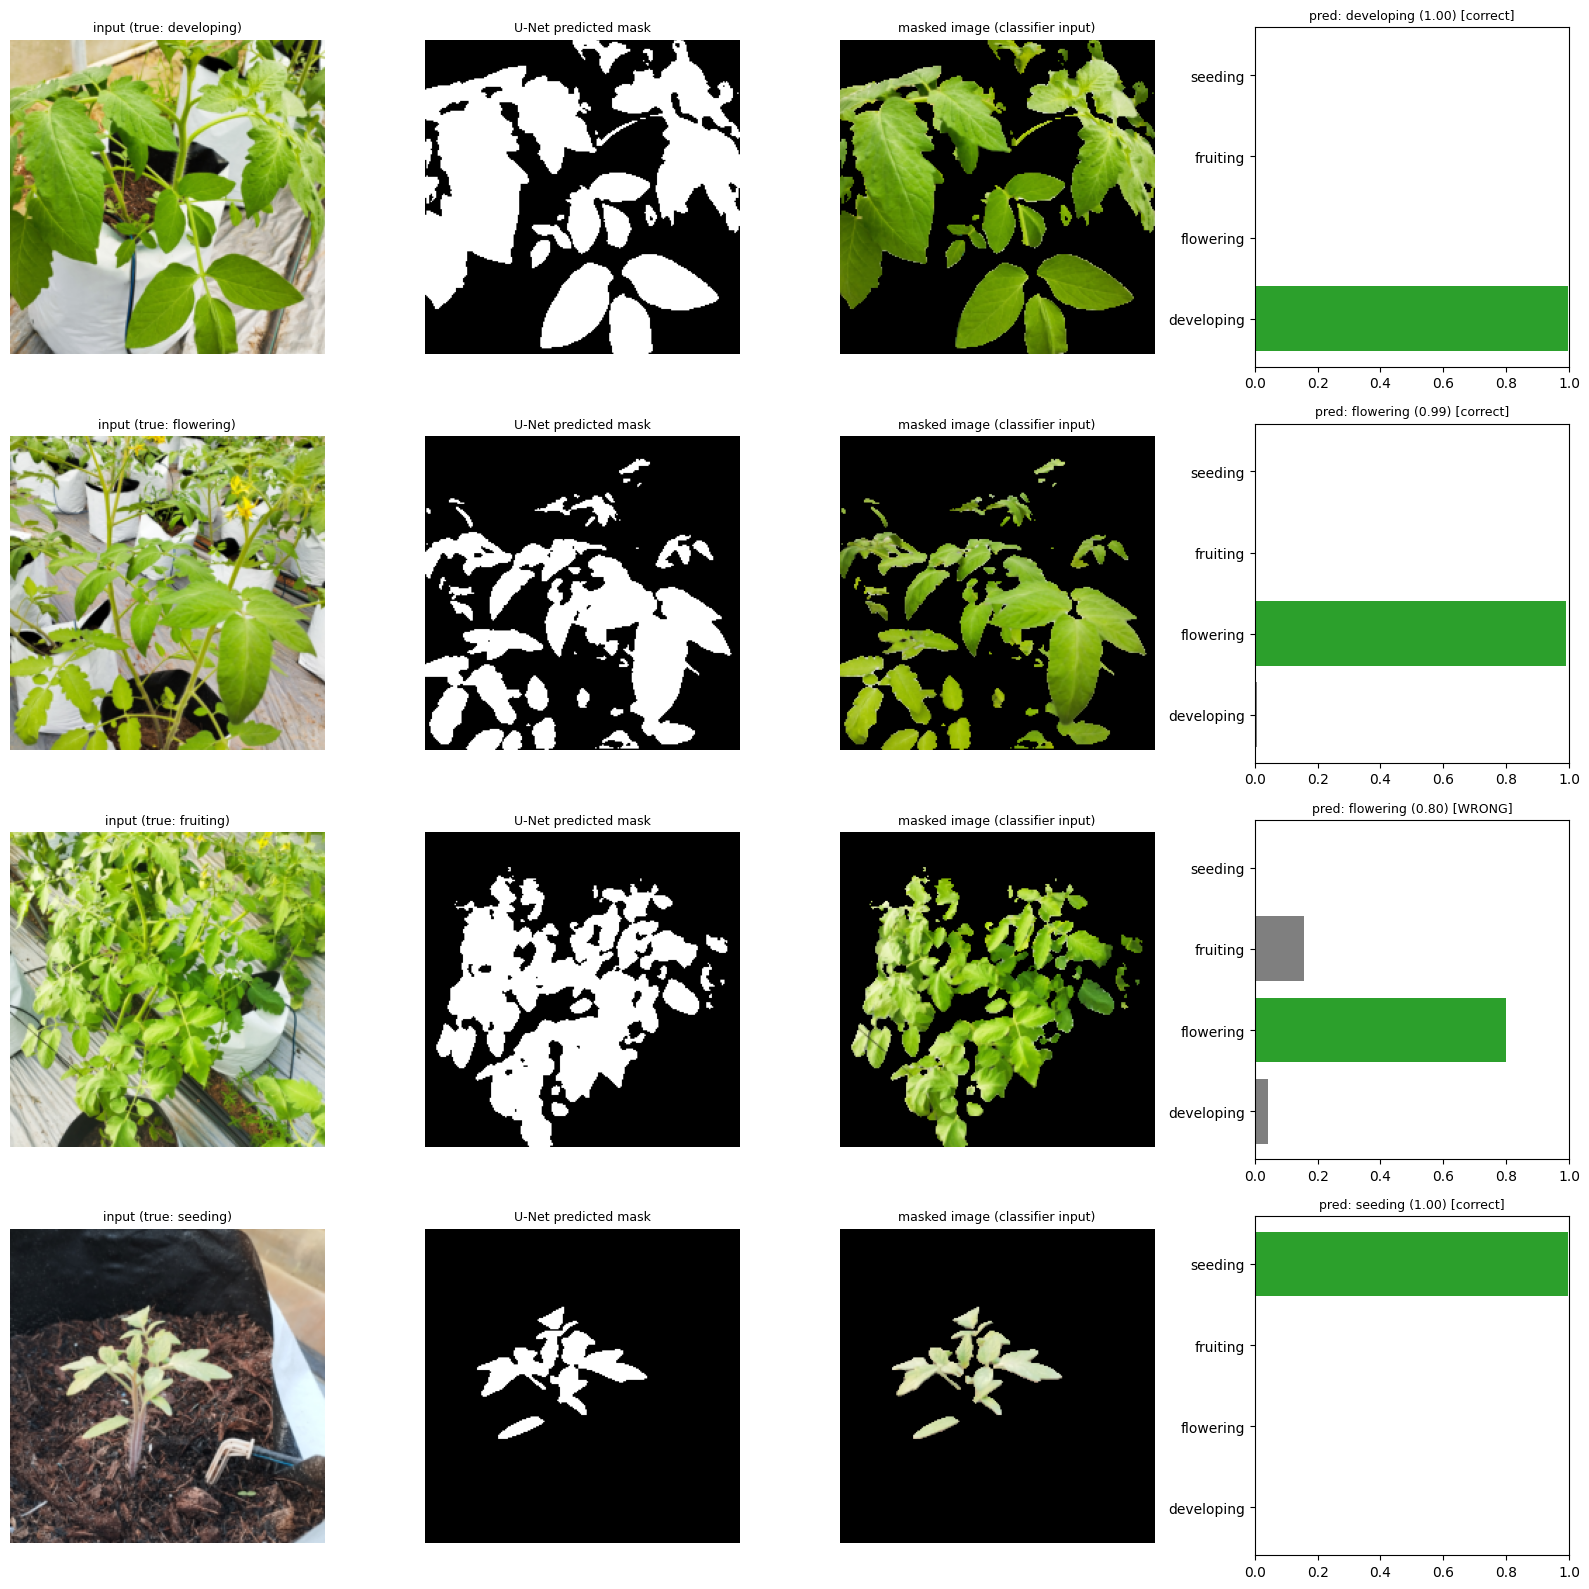

In [8]:
examples = []
seen = set()
for path, cls, image_entry in test_samples:
    if cls in seen:
        continue
    seen.add(cls)
    examples.append((path, cls))
    if len(examples) == len(CLASS_NAMES):
        break

fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))
for row, (path, true_cls) in enumerate(examples):
    pred_label, conf, probs, mask, raw01 = predict_growth_stage(path)

    axes[row, 0].imshow(raw01)
    axes[row, 0].set_title(f"input (true: {true_cls})", fontsize=9)
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("U-Net predicted mask", fontsize=9)
    axes[row, 2].imshow(raw01 * mask[..., None])
    axes[row, 2].set_title("masked image (classifier input)", fontsize=9)

    colors = ["tab:green" if c == pred_label else "tab:gray" for c in CLASS_NAMES]
    axes[row, 3].barh(CLASS_NAMES, [probs[c] for c in CLASS_NAMES], color=colors)
    axes[row, 3].set_xlim(0, 1)
    correct = "correct" if pred_label == true_cls else "WRONG"
    axes[row, 3].set_title(f"pred: {pred_label} ({conf:.2f}) [{correct}]", fontsize=9)

    for c in range(3):
        axes[row, c].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pipeline_walkthrough.png"), dpi=150)
plt.show()


## 6. Segmentation quality on the test set (U-Net alone)

Foreground-only IoU/Dice — same metric definition as `unet_pipeline.ipynb`'s own
evaluation, just recomputed on this crop-aligned frame instead of U-Net's native
direct-resize frame.

In [9]:
def foreground_iou_dice(pred, target, eps=1e-6):
    pred = pred.astype(np.float32).flatten()
    target = target.astype(np.float32).flatten()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)
    return float(iou), float(dice)


fg_ious, fg_dices = [], []
per_stage = {c: {"iou": [], "dice": []} for c in CLASS_NAMES}

for path, cls, image_entry in test_samples:
    _, _, _, pred_mask, _ = predict_growth_stage(path)
    target_mask = gt_mask_cropped(image_entry)
    iou, dice = foreground_iou_dice(pred_mask, target_mask)
    fg_ious.append(iou)
    fg_dices.append(dice)
    per_stage[cls]["iou"].append(iou)
    per_stage[cls]["dice"].append(dice)

print(f"foreground IoU:  {np.mean(fg_ious):.4f}")
print(f"foreground Dice: {np.mean(fg_dices):.4f}")
print()
for cls in CLASS_NAMES:
    d = per_stage[cls]
    print(f"  {cls:<12} iou={np.mean(d['iou']):.4f}  dice={np.mean(d['dice']):.4f}  n={len(d['iou'])}")


foreground IoU:  0.6698
foreground Dice: 0.7843

  developing   iou=0.6744  dice=0.7826  n=41
  flowering    iou=0.6381  dice=0.7709  n=60
  fruiting     iou=0.5014  dice=0.6330  n=21
  seeding      iou=0.8079  dice=0.8910  n=38


## 7. Full pipeline evaluation on the test set

Runs the complete segment -> mask -> classify pipeline on every test image and compares
the predicted growth stage to ground truth. Expected to land close to the previously
benchmarked **89.4%** (same models, same preprocessing, same test set).

full pipeline test accuracy: 0.8938

              precision    recall  f1-score   support

  developing       0.95      0.95      0.95        41
   flowering       0.86      0.85      0.86        60
    fruiting       0.68      0.71      0.70        21
     seeding       1.00      1.00      1.00        38

    accuracy                           0.89       160
   macro avg       0.87      0.88      0.88       160
weighted avg       0.89      0.89      0.89       160



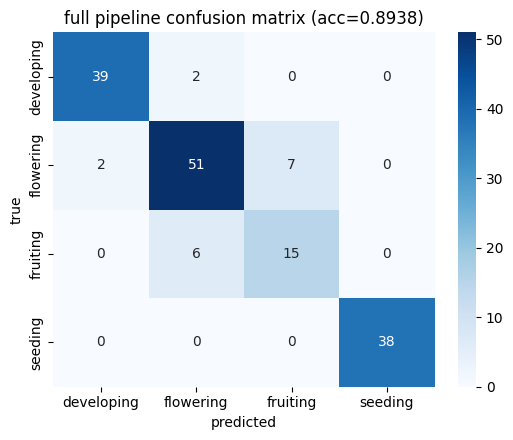

In [10]:
all_preds, all_labels = [], []
for path, cls, image_entry in test_samples:
    pred_label, conf, probs, mask, raw01 = predict_growth_stage(path)
    all_preds.append(pred_label)
    all_labels.append(cls)

pipeline_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"full pipeline test accuracy: {pipeline_accuracy:.4f}")
print()
print(classification_report(all_labels, all_preds, labels=CLASS_NAMES, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds, labels=CLASS_NAMES)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title(f"full pipeline confusion matrix (acc={pipeline_accuracy:.4f})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "full_pipeline_confusion_matrix.png"), dpi=150)
plt.show()


### Per-image results (for closer inspection / thesis appendix)

In [11]:
results_df = pd.DataFrame({
    "filename": [os.path.basename(p) for p, _, _ in test_samples],
    "true_stage": all_labels,
    "pred_stage": all_preds,
    "correct": np.array(all_labels) == np.array(all_preds),
})
results_df.to_csv(os.path.join(OUTPUT_DIR, "full_pipeline_test_results.csv"), index=False)
print(f"accuracy by true stage:")
print(results_df.groupby("true_stage")["correct"].agg(["mean", "count"]))
results_df.head()


accuracy by true stage:
                mean  count
true_stage                 
developing  0.951220     41
flowering   0.850000     60
fruiting    0.714286     21
seeding     1.000000     38


,filename,true_stage,pred_stage,correct
0,photo_dev (103)_jpg.rf.RWQrfFCEy7p25IXgGCmv.jpg,developing,developing,True
1,photo_dev (105)_jpg.rf.3NfhXjBV6AbRwed52X0a.jpg,developing,developing,True
2,photo_dev (110)_jpg.rf.u1FamS2UASM9x8C0OBuA.jpg,developing,developing,True
3,photo_dev (117)_jpg.rf.R4PgPoxztqDX741BLJhY.jpg,developing,developing,True
4,photo_dev (13)_jpg.rf.OdDShvsZNvOiHWprNo0u.jpg,developing,developing,True
